In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.transforms as transforms
import matplotlib.animation as animation
from IPython.display import HTML
import numpy as np
import xml.etree.ElementTree as ET
import json
import os

In [27]:
ID = 0
RUN = f"argos_runner/results/run_{ID}"

In [28]:
cell_size = 0.15

In [29]:
tree = ET.parse(os.path.join(RUN, 'projet.argos'))
root = tree.getroot()

data = {'walls': [], 'target': {}}

for box in root.findall('.//arena/box'):
    box_id = box.get('id')
    sx, sy = map(float, box.get('size').split(',')[:2])
    body = box.find('body')
    x, y = map(float, body.get('position').split(',')[:2])
    yaw = float(body.get('orientation').split(',')[0])
    
    data['walls'].append({
        'id': box_id, 'x': x, 'y': y, 'sx': sx, 'sy': sy, 'yaw': yaw
    })

light = root.find('.//arena/light')
if light is not None:
    x, y = map(float, light.get('position').split(',')[:2])
    data['target'] = {
        'id': light.get('id'),
        'x': x,
        'y': y,
        'color': light.get('color')
    }

start_pos = root.find('.//arena/distribute/position')
if start_pos is not None:
    min_x, min_y = start_pos.get("min").split(',')[:2]
    max_x, max_y = start_pos.get("max").split(',')[:2]
    data['start'] = {
        'min_x': min(float(min_x), float(max_x)),
        'min_y': min(float(min_y), float(max_y)),
        'max_x': max(float(min_x), float(max_x)),
        'max_y': max(float(min_y), float(max_y)),
    }

with open('arena.json', 'w') as f:
    json.dump(data, f, indent=4)

In [30]:
df = pd.read_csv(os.path.join(RUN, "experiment_data.csv"), names=["robot_id", "step", "x", "y", "arrived"])

In [31]:
with open(os.path.join(RUN, 'arena.json'), 'r') as f:
    arena = json.load(f)

In [32]:
groups = df.groupby("robot_id")

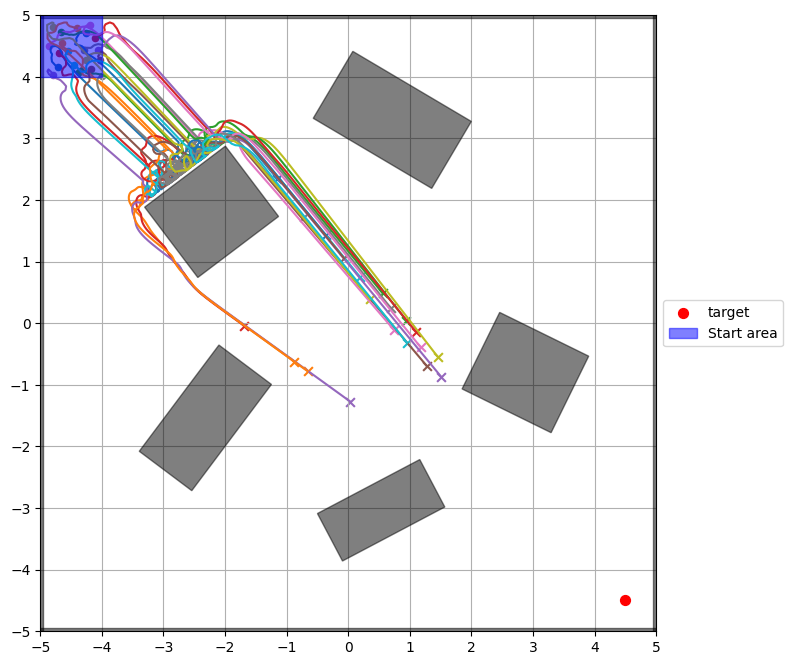

In [33]:
fig, ax = plt.subplots(figsize=(8, 8))

for robot_id, group in groups:
    line, = ax.plot(group["x"], group["y"]) # label=f"agent {robot_id}"
    c = line.get_color()
    ax.scatter(group["x"].iloc[0], group["y"].iloc[0], marker="o", s=20, color=c)
    ax.scatter(group["x"].iloc[-1], group["y"].iloc[-1], marker="x", s=40, color=c)

for w in arena.get('walls', []):
    rect = patches.Rectangle(
        (w['x'] - w['sx'] / 2, w['y'] - w['sy'] / 2),
        w['sx'], w['sy'],
        color='black', alpha=0.5, zorder=2
    )
    t = transforms.Affine2D().rotate_around(w['x'], w['y'], np.radians(w['yaw'])) + ax.transData
    rect.set_transform(t)
    ax.add_patch(rect)

target = arena.get('target')
if target:
    ax.scatter(target['x'], target['y'], color="red", marker="o", s=50, label="target", zorder=5)

start = arena.get('start')
if start:
    x = start['min_x']
    y = start['min_y']
    sx = start['max_x'] - start['min_x']
    sy = start['max_y'] - start['min_y']
    rect = patches.Rectangle(
        (x, y),
        sx, sy,
        color='blue', alpha=0.5, zorder=2
    )
    t = transforms.Affine2D() + ax.transData
    rect.set_transform(t)
    ax.add_patch(rect)
    rect.set_label("Start area")

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_xticks(np.arange(-5, 6, 1))
ax.set_yticks(np.arange(-5, 6, 1))
ax.grid(True)
ax.set_aspect("equal")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

plt.show()

In [34]:
target_x = arena['target']['x']
target_y = arena['target']['y']

GOAL_THRESH = 0.50
TICKS_PER_SEC = 10.0

num_agents = len(df['robot_id'].unique())
reached_count = 0
times_to_target = []
total_distance = 0.0

for robot_id, group in df.groupby('robot_id'):
    group = group.sort_values('step')
    
    dist_to_target = np.sqrt((group['x'] - target_x)**2 + (group['y'] - target_y)**2)
    reached_mask = dist_to_target < GOAL_THRESH
    
    if reached_mask.any():
        reached_count += 1
        first_reached_idx = reached_mask.idxmax()
        steps_to_target = group.loc[first_reached_idx, 'step']
        times_to_target.append(steps_to_target)
        
        valid_steps = group[group['step'] <= steps_to_target]
        dist_traveled = np.sqrt(valid_steps['x'].diff()**2 + valid_steps['y'].diff()**2).sum()
        total_distance += dist_traveled
    else:
        dist_traveled = np.sqrt(group['x'].diff()**2 + group['y'].diff()**2).sum()
        total_distance += dist_traveled

mean_time_sec = np.mean(times_to_target) / TICKS_PER_SEC if times_to_target else 0
fastest_time_sec = np.min(times_to_target) / TICKS_PER_SEC if times_to_target else 0
slowest_time_sec = np.max(times_to_target) / TICKS_PER_SEC if times_to_target else 0

print(f"Number of agents: {num_agents}")
print(f"Successfully reached target: {reached_count}")
print(f"Mean time to target: {mean_time_sec:.2f} s")
print(f"Fastest time to target: {fastest_time_sec:.2f} s")
print(f"Slowest time to target: {slowest_time_sec:.2f} s")
print(f"Total traveled distance: {total_distance:.2f} cm")

Number of agents: 20
Successfully reached target: 0
Mean time to target: 0.00 s
Fastest time to target: 0.00 s
Slowest time to target: 0.00 s
Total traveled distance: 179.72 cm


In [35]:
def animate_map(log_file):
    steps = []
    grid_events = {}

    with open(log_file, "r") as f:
        for line in f:
            parts = line.strip().split(",")
            if parts[0] == "MAP" and len(parts) >= 5:
                step = int(parts[1])
                x, y, val = int(parts[2]), int(parts[3]), int(parts[4])
                
                if step not in grid_events:
                    grid_events[step] = []
                    steps.append(step)
                grid_events[step].append(((x, y), val))

    steps = sorted(list(set(steps)))
    if not steps:
        return "No map data found."

    fig, ax = plt.subplots(figsize=(8, 8))
    scat_free = ax.scatter([], [], c="lightgray", marker="s", s=25, label="Explored", zorder=5)
    scat_obs = ax.scatter([], [], c="black", marker="s", s=25, label="Obstacle", zorder=5)
    
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_xticks(np.arange(-5, 6, 1))
    ax.set_yticks(np.arange(-5, 6, 1))
    ax.grid(True)
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    ax.set_aspect("equal")

    cumulative_grid = {}

    def update(frame):
        step = steps[frame]
        for pos, val in grid_events[step]:
            cumulative_grid[pos] = val

        free_x = [p[0]*0.15 for p, v in cumulative_grid.items() if v == 1]
        free_y = [p[1]*0.15 for p, v in cumulative_grid.items() if v == 1]
        obs_x = [p[0]*0.15 for p, v in cumulative_grid.items() if v == 2]
        obs_y = [p[1]*0.15 for p, v in cumulative_grid.items() if v == 2]

        if free_x:
            scat_free.set_offsets(np.c_[free_x, free_y])
        if obs_x:
            scat_obs.set_offsets(np.c_[obs_x, obs_y])

        ax.set_title(f"Step {step}")
        return scat_free, scat_obs

    ani = animation.FuncAnimation(fig, update, frames=len(steps), interval=200, blit=False)
    plt.close(fig)
    
    return HTML(ani.to_jshtml())

In [36]:
def display_map(log_file):
    grid = {}
    with open(log_file, "r") as f:
        for line in f:
            parts = line.strip().split(",")
            if parts[0] == "MAP" and len(parts) >= 5:
                grid[(int(float(parts[2])), int(float(parts[3])))] = int(float(parts[4]))

    free_x = [pos[0]*cell_size for pos, val in grid.items() if val == 1]
    free_y = [pos[1]*cell_size for pos, val in grid.items() if val == 1]
    obs_x = [pos[0]*cell_size for pos, val in grid.items() if val == 2]
    obs_y = [pos[1]*cell_size for pos, val in grid.items() if val == 2]
    frontiere_x = [pos[0]*cell_size for pos, val in grid.items() if val == -1]
    frontiere_y = [pos[1]*cell_size for pos, val in grid.items() if val == -1]

    plt.figure(figsize=(10, 10))

    plt.xlim(-5, 5)
    plt.ylim(-5, 5)
    plt.xticks(np.arange(-5, 6, 1))
    plt.yticks(np.arange(-5, 6, 1))
    plt.grid(True)
    plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))

    plt.scatter(free_x, free_y, c="lightgray", marker="s", s=cell_size*250, label="Explored", zorder=5)
    plt.scatter(obs_x, obs_y, c="black", marker="s", s=cell_size*250, label="Obstacle", zorder=5)
    plt.scatter(frontiere_x, frontiere_y, c="green", marker="s", s=cell_size*250, label="Obstacle", zorder=5)

    plt.show()

In [37]:
# display_map("experiment_map.csv")

In [38]:
# animate_map("experiment_map.csv")